#### Importando Bibliotecas

In [204]:
import pandas as pd
import matplotlib.pyplot as plt

#### Entrada dos dados

In [205]:
df_andando = pd.read_csv("./arduino-science-jorunal/Andando.csv")
df_caminhando = pd.read_csv("./arduino-science-jorunal/Caminhando.csv")
df_correndo = pd.read_csv("./arduino-science-jorunal/Correndo.csv")

In [162]:
df_andando.head()

,timestamp,AmbientLightSensor,DecibelSource,PitchSensor,AccX,AccY,AccZ
0,1763074334936,1.0,NaN,NaN,-0.07605,2.08500,9.391951
1,1763074334953,NaN,48.155316,162.535924,NaN,NaN,NaN
2,1763074334958,NaN,NaN,85.885417,NaN,NaN,NaN
3,1763074334993,NaN,47.077705,85.885417,NaN,NaN,NaN
4,1763074335005,NaN,NaN,NaN,0.37305,2.07795,9.399000


In [206]:
df_caminhando.head()

,timestamp,AmbientLightSensor,DecibelSource,PitchSensor,AccX,AccY,AccZ
0,1763074862430,11.0,NaN,NaN,-0.15705,NaN,NaN
1,1763074862441,12.0,NaN,NaN,NaN,NaN,NaN
2,1763074862443,NaN,NaN,NaN,NaN,5.322,NaN
3,1763074862444,NaN,NaN,NaN,NaN,NaN,8.632951
4,1763074862447,NaN,NaN,NaN,-1.15095,NaN,NaN


In [207]:
df_correndo.head()

,timestamp,AmbientLightSensor,DecibelSource,PitchSensor,AccX,AccY,AccZ
0,1763141947708,NaN,NaN,NaN,2.622,-7.249050,6.73200
1,1763141947725,NaN,NaN,NaN,1.875,-9.009001,1.40205
2,1763141947727,NaN,67.496179,73.620199,NaN,NaN,NaN
3,1763141947744,NaN,NaN,NaN,0.330,-11.049001,NaN
4,1763141947745,NaN,NaN,NaN,NaN,NaN,-0.78795


#### Tamanho dos datasets

In [208]:
print(f"Número de instâncias(Andando): {len(df_andando['timestamp'])}")
print(f"Número de instâncias(Caminhando): {len(df_caminhando['timestamp'])}")
print(f"Número de instâncias(Correndo): {len(df_correndo['timestamp'])}")

Número de instâncias(Andando): 9660
Número de instâncias(Caminhando): 4833
Número de instâncias(Correndo): 3714


#### Verificar potenciais tratamentos de dados 

In [209]:
df_andando.dtypes

timestamp               int64
AmbientLightSensor    float64
DecibelSource         float64
PitchSensor           float64
AccX                  float64
AccY                  float64
AccZ                  float64
dtype: object

In [210]:
df_caminhando.dtypes

timestamp               int64
AmbientLightSensor    float64
DecibelSource         float64
PitchSensor           float64
AccX                  float64
AccY                  float64
AccZ                  float64
dtype: object

In [211]:
df_correndo.dtypes

timestamp               int64
AmbientLightSensor    float64
DecibelSource         float64
PitchSensor           float64
AccX                  float64
AccY                  float64
AccZ                  float64
dtype: object

#### Filtrando as features

In [212]:
df_filtrar_andando = df_andando[['timestamp', 'AccX', 'AccY', 'AccZ']]
df_filtrar_caminhando = df_caminhando[['timestamp', 'AccX', 'AccY', 'AccZ']]
df_filtrar_correndo = df_correndo[['timestamp', 'AccX', 'AccY', 'AccZ']]

In [213]:
df_filtrar_andando.head

<bound method NDFrame.head of           timestamp     AccX     AccY      AccZ
0     1763074334936 -0.07605  2.08500  9.391951
1     1763074334953      NaN      NaN       NaN
2     1763074334958      NaN      NaN       NaN
3     1763074334993      NaN      NaN       NaN
4     1763074335005  0.37305  2.07795  9.399000
...             ...      ...      ...       ...
9655  1763074424393      NaN      NaN       NaN
9656  1763074424404  0.47400  4.35705  8.496000
9657  1763074424405      NaN      NaN       NaN
9658  1763074424426      NaN  4.36200       NaN
9659  1763074424427  0.46005      NaN  8.491051

[9660 rows x 4 columns]>

#### Filtrando as Instâncias

In [214]:
df_filtrar_andando = df_filtrar_andando.dropna()
df_filtrar_caminhando = df_filtrar_caminhando.dropna()
df_filtrar_correndo = df_filtrar_correndo.dropna()

In [215]:
len(df_filtrar_andando)

3046

In [216]:

df_filtrar_andando.head()

,timestamp,AccX,AccY,AccZ
0,1763074334936,-0.07605,2.08500,9.391951
4,1763074335005,0.37305,2.07795,9.399000
5,1763074335021,2.26995,1.29705,9.388950
7,1763074335040,2.24805,0.94500,9.382051
9,1763074335059,1.75995,0.62895,8.950951


In [217]:
len(df_filtrar_caminhando)

843

In [218]:
len(df_filtrar_correndo)

731

In [219]:
df_filtrar_caminhando.head()

,timestamp,AccX,AccY,AccZ
7,1763074862463,-1.14795,4.02705,8.635051
8,1763074862487,-1.14105,2.94195,8.641951
10,1763074862503,-1.50795,2.96400,9.777000
17,1763074862562,-0.93300,3.82605,10.246051
19,1763074862589,-0.39405,3.83505,9.777000


In [220]:
len(df_filtrar_correndo)

731

In [221]:
df_filtrar_correndo.head()

,timestamp,AccX,AccY,AccZ
0,1763141947708,2.622000,-7.249050,6.73200
1,1763141947725,1.875000,-9.009001,1.40205
6,1763141947763,-0.652950,-14.439001,-2.77005
8,1763141947782,3.009000,-17.995050,-4.31505
18,1763141947860,28.518002,-5.590050,-4.31505


#### Nivelamento do Dataset

In [223]:
# Nível desejado
nivel_desejado = len(df_filtrar_correndo)  # 730

In [224]:
# Reduzir os outros DataFrames para 730 linhas (amostra aleatória)
df_filtrar_andando = df_filtrar_andando.sample(n=nivel_desejado, random_state=42)
df_filtrar_caminhando = df_filtrar_caminhando.sample(n=nivel_desejado, random_state=42)

In [225]:
# Verificar
print(f"Andando: {len(df_filtrar_andando)} linhas")
print(f"Caminhando: {len(df_filtrar_caminhando)} linhas") 
print(f"Correndo: {len(df_filtrar_correndo)} linhas")

Andando: 731 linhas
Caminhando: 731 linhas
Correndo: 731 linhas


#### Conferindo se tem Células Núlas

In [226]:
len(df_filtrar_caminhando)

731

In [227]:
len(df_filtrar_caminhando)


731

In [228]:
len(df_filtrar_caminhando)

731

In [229]:
df_filtrar_correndo.isna().any().any()


False

In [230]:
df_filtrar_caminhando.isna().any().any()


False

In [231]:
df_filtrar_andando.isna().any().any()

False

##### Resetar Índice

In [232]:
# Resetar índice começando do 1 (em vez do 0 padrão)
df_filtrar_correndo = df_filtrar_correndo.reset_index(drop=True)
df_filtrar_correndo.index = df_filtrar_correndo.index + 1

df_filtrar_andando = df_filtrar_andando.reset_index(drop=True)
df_filtrar_andando.index = df_filtrar_andando.index + 1

df_filtrar_caminhando = df_filtrar_caminhando.reset_index(drop=True)
df_filtrar_caminhando.index = df_filtrar_caminhando.index + 1

In [233]:
df_filtrar_correndo.head()

,timestamp,AccX,AccY,AccZ
1,1763141947708,2.622000,-7.249050,6.73200
2,1763141947725,1.875000,-9.009001,1.40205
3,1763141947763,-0.652950,-14.439001,-2.77005
4,1763141947782,3.009000,-17.995050,-4.31505
5,1763141947860,28.518002,-5.590050,-4.31505


In [234]:
df_filtrar_caminhando.head()


,timestamp,AccX,AccY,AccZ
1,1763074886587,5.86095,5.25495,6.163950
2,1763074873489,5.16195,7.95600,3.669000
3,1763074892646,-9.35805,2.28105,1.495050
4,1763074899122,4.08705,5.81505,5.869950
5,1763074865448,-1.60800,4.75995,10.167001


In [235]:
df_filtrar_andando.head()

,timestamp,AccX,AccY,AccZ
1,1763074366698,14.610001,-5.55405,0.00795
2,1763074355548,10.020000,-4.02405,-1.63995
3,1763074402851,10.200001,-1.06500,-1.67595
4,1763074378178,12.520051,-2.92500,-2.83005
5,1763074402251,11.184001,-1.74000,-0.69495


In [239]:
# Remover a última linha de cada DataFrame
df_filtrar_correndo = df_filtrar_correndo.iloc[:-1]  # Remove última linha
df_filtrar_andando = df_filtrar_andando.iloc[:-1]    # Remove última linha  
df_filtrar_caminhando = df_filtrar_caminhando.iloc[:-1]  # Remove última linha

In [240]:
len(df_filtrar_andando)

730

In [241]:
len(df_filtrar_caminhando)

730

In [242]:
len(df_filtrar_correndo)

730

#### Concatenação dos Dataframes

In [243]:
# Pegar apenas as primeiras 10 linhas de cada atividade
correndo_10 = df_filtrar_correndo.head(10).assign(atividade='Correndo')
andando_10 = df_filtrar_andando.head(10).assign(atividade='Andando')
caminhando_10 = df_filtrar_caminhando.head(10).assign(atividade='Caminhando')

# Concatenar na sequência desejada
df_sequencia = pd.concat([
    correndo_10,
    andando_10,
    caminhando_10
], ignore_index=True)

# Resetar índice para 1, 2, 3...
df_sequencia.index = df_sequencia.index + 1

In [244]:
df_sequencia.head(60)

,timestamp,AccX,AccY,AccZ,atividade
1,1763141947708,2.622000,-7.249050,6.732000,Correndo
2,1763141947725,1.875000,-9.009001,1.402050,Correndo
3,1763141947763,-0.652950,-14.439001,-2.770050,Correndo
4,1763141947782,3.009000,-17.995050,-4.315050,Correndo
5,1763141947860,28.518002,-5.590050,-4.315050,Correndo
6,1763141947899,50.128952,8.767950,-2.785050,Correndo
7,1763141947938,31.345951,13.824000,0.612000,Correndo
8,1763141947977,12.964951,14.557051,6.882000,Correndo
9,1763141947996,8.812950,15.088951,7.708050,Correndo
10,1763141948016,4.590000,15.097951,7.708050,Correndo


#### Visualização das Amostras

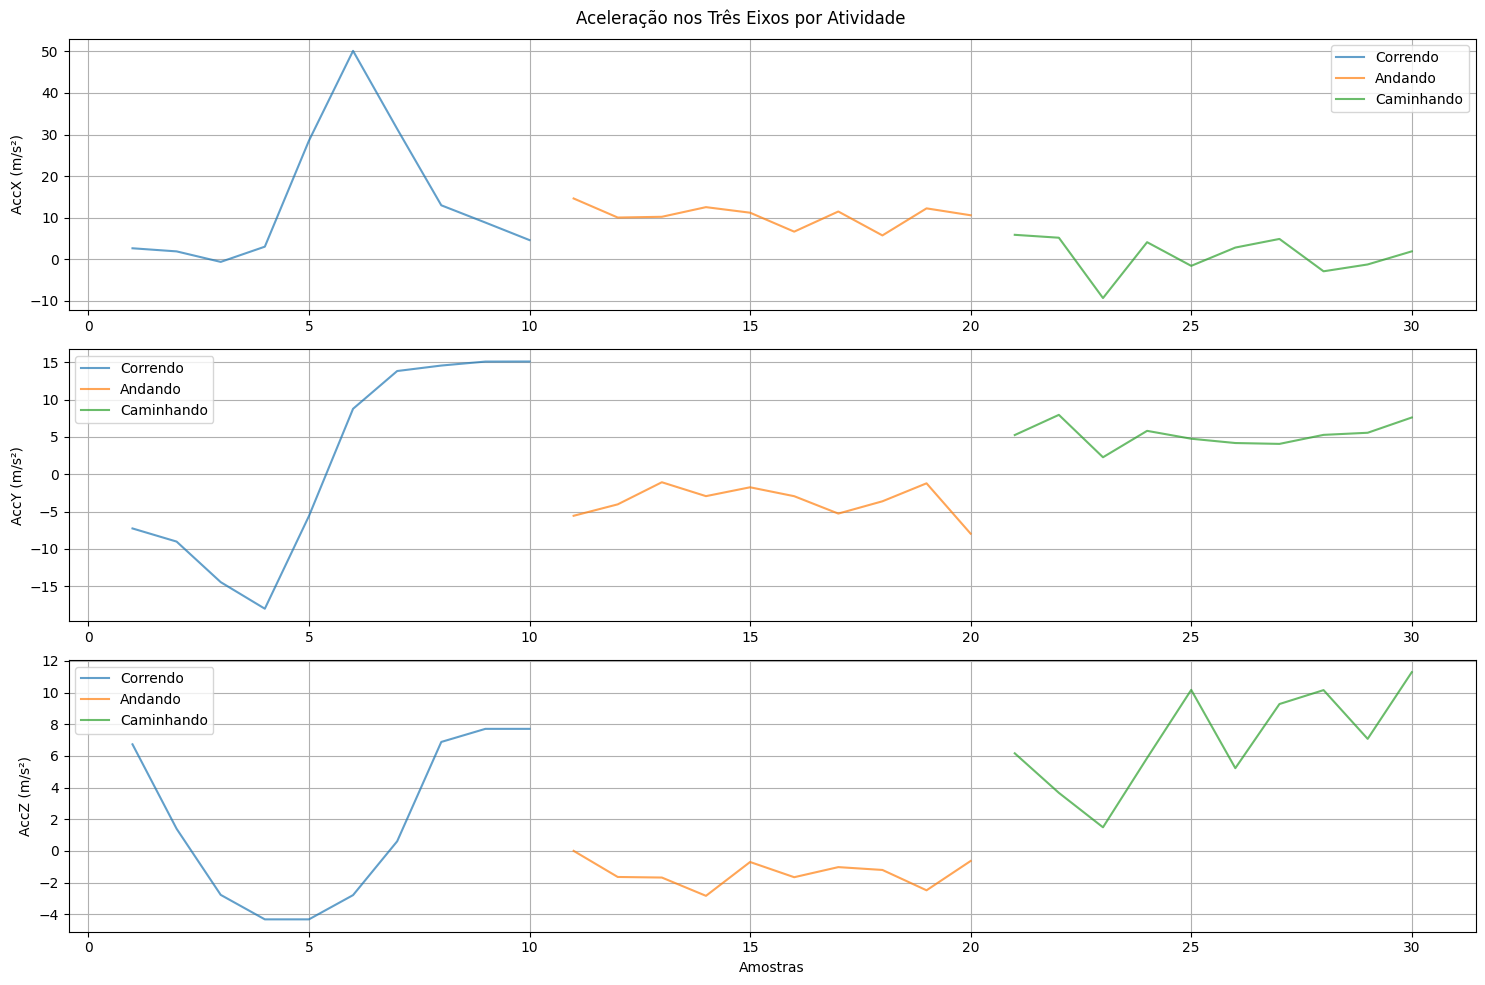

In [245]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot cada eixo separadamente
for i, eixo in enumerate(['AccX', 'AccY', 'AccZ']):
    for atividade in df_sequencia['atividade'].unique():
        dados = df_sequencia[df_sequencia['atividade'] == atividade]
        axes[i].plot(dados.index, dados[eixo], label=atividade, alpha=0.7)
    
    axes[i].set_ylabel(f'{eixo} (m/s²)')
    axes[i].legend()
    axes[i].grid(True)

axes[2].set_xlabel('Amostras')
plt.suptitle('Aceleração nos Três Eixos por Atividade')
plt.tight_layout()
plt.show()